## evaluate-lastfm.ipynb

Evaluates the three KNN models against Last.fm album similarity data.

### Scope alignment
The KNN models are built on **studio albums only** (`release_group.type = 1`).
Last.fm similarity data includes singles, EPs, deluxe editions, remixes and
soundtrack contributions — these will never appear in model results, artificially
capping scores. The evaluation therefore filters ground truth to only
seed/similar pairs where **both** albums are present in the MusicBrainz studio
album index before computing any metrics.

### Metrics
| Metric | Description |
|---|---|
| **Hit Rate @10** | Fraction of seed albums where at least 1 known similar album appears in the top 10 |
| **Precision @10** | Average fraction of the 10 results that are known similar albums |
| **MRR @10** | Mean Reciprocal Rank — rewards finding a known similar album higher in the list |

In [1]:
import pickle
import numpy as np
import pandas as pd
import joblib
from scipy.sparse import load_npz
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR     = '../data'
FEATURES_DIR = f'{DATA_DIR}/features'

# Path to the Last.fm similarity CSV / parquet
# Change extension to .csv and adjust read call below if needed
LASTFM_PATH  = f'{DATA_DIR}/lastfm_album_similarity.parquet'

N_RESULTS    = 10   # number of recommendations to evaluate against

In [2]:
def load_model(model_path, matrix_path, ids_path):
    model               = joblib.load(model_path)
    X                   = load_npz(matrix_path)
    album_ids_annotated = np.load(ids_path, allow_pickle=True)
    album_id_to_row     = {aid: i for i, aid in enumerate(album_ids_annotated)}
    return model, X, album_ids_annotated, album_id_to_row

model_v1, X_v1, ids_v1, id2row_v1 = load_model(
    f'{DATA_DIR}/model/knn_model.joblib',
    f'{DATA_DIR}/model/X_knn_norm.npz',
    f'{DATA_DIR}/model/album_ids_annotated.npy'
)
model_v2, X_v2, ids_v2, id2row_v2 = load_model(
    f'{DATA_DIR}/model_v2/knn_model_v2.joblib',
    f'{DATA_DIR}/model_v2/X_knn_norm_v2.npz',
    f'{DATA_DIR}/model_v2/album_ids_annotated_v2.npy'
)
model_v3, X_v3, ids_v3, id2row_v3 = load_model(
    f'{DATA_DIR}/model_v3/knn_model_v3.joblib',
    f'{DATA_DIR}/model_v3/X_knn_norm_v3.npz',
    f'{DATA_DIR}/model_v3/album_ids_annotated_v3.npy'
)

print('Models loaded.')
for label, ids in [('v1', ids_v1), ('v2', ids_v2), ('v3', ids_v3)]:
    print(f'  {label}: {len(ids):,} annotated albums')

Models loaded.
  v1: 1,008,102 annotated albums
  v2: 1,008,102 annotated albums
  v3: 1,008,102 annotated albums


In [3]:
# Album name+artist → MusicBrainz album_id lookup
# We match on both album name and artist name (lowercased, stripped)
mb_lookup = (
    pd.read_parquet(f'{DATA_DIR}/mb_album_artists.parquet',
                    columns=['album_id', 'album_name', 'artist_name'])
    .drop_duplicates(subset='album_id')
)

mb_lookup['album_key']  = mb_lookup['album_name'].str.lower().str.strip()
mb_lookup['artist_key'] = mb_lookup['artist_name'].str.lower().str.strip()

# Primary join key: exact album + artist match
mb_index = mb_lookup.set_index(['album_key', 'artist_key'])['album_id']

print(f'MusicBrainz lookup: {len(mb_lookup):,} albums')

MusicBrainz lookup: 2,241,402 albums


In [6]:
# Load Last.fm ground truth
# Switch to pd.read_csv() if you have a .csv file
try:
    lastfm = pd.read_parquet(LASTFM_PATH)
except Exception:
    lastfm = pd.read_csv(LASTFM_PATH.replace('.parquet', '.csv'))

lastfm.columns = lastfm.columns.str.strip()
lastfm['album_key']          = lastfm['album'].str.lower().str.strip()
lastfm['artist_key']         = lastfm['artist'].str.lower().str.strip()
lastfm['similar_album_key']  = lastfm['similar_album'].str.lower().str.strip()
lastfm['similar_artist_key'] = lastfm['similar_artist'].str.lower().str.strip()

print(f'Last.fm rows loaded    : {len(lastfm):,}')
print(f'Unique seed albums     : {lastfm[["album_key","artist_key"]].drop_duplicates().shape[0]:,}')
print(f'Unique similar albums  : {lastfm[["similar_album_key","similar_artist_key"]].drop_duplicates().shape[0]:,}')
lastfm.head(3)

Last.fm rows loaded    : 77,062
Unique seed albums     : 6,473
Unique similar albums  : 14,290


,album,artist,tag,similar_album,similar_artist,similarity_rank,album_key,artist_key,similar_album_key,similar_artist_key
0,Starboy,The Weeknd,Electronic,Late Nights: The Album,Jeremih,1,starboy,the weeknd,late nights: the album,jeremih
1,Starboy,The Weeknd,Electronic,Jeremih,Jeremih,2,starboy,the weeknd,jeremih,jeremih
2,Starboy,The Weeknd,Electronic,SOS,SZA,4,starboy,the weeknd,sos,sza


In [8]:
# Match seed albums to MusicBrainz IDs
seed_pairs = lastfm[['album_key', 'artist_key']].drop_duplicates()
seed_pairs = seed_pairs.join(
    mb_index.rename('seed_mb_id'),
    on=['album_key', 'artist_key'],
    how='left'
)

# Match similar albums to MusicBrainz IDs
lastfm = lastfm.join(
    mb_index.rename('similar_mb_id'),
    on=['similar_album_key', 'similar_artist_key'],
    how='left'
)

# Merge seed IDs back into main table
lastfm = lastfm.merge(seed_pairs, on=['album_key', 'artist_key'], how='left')

matched_seeds   = seed_pairs['seed_mb_id'].notna().sum()
matched_similar = lastfm['similar_mb_id'].notna().sum()
total_seeds     = len(seed_pairs)
total_similar   = len(lastfm)

print(f'Seed albums matched to MusicBrainz : {matched_seeds:,} / {total_seeds:,}  ({matched_seeds/total_seeds*100:.1f}%)')
print(f'Similar albums matched             : {matched_similar:,} / {total_similar:,}  ({matched_similar/total_similar*100:.1f}%)')

Seed albums matched to MusicBrainz : 2,498 / 6,982  (35.8%)
Similar albums matched             : 56,546 / 105,479  (53.6%)


In [9]:
# Build ground-truth dict: seed_mb_id → set of known similar mb_ids
#
# SCOPE FILTER: only keep similar albums that are themselves present in
# the MusicBrainz studio-album index (union of all three model indices).
# This ensures the evaluation is fair — the model can only be blamed for
# missing albums it was actually built to recommend.

# Union of all annotated album IDs across the three models
all_model_ids = set(ids_v1) | set(ids_v2) | set(ids_v3)

gt_raw = (
    lastfm
    .dropna(subset=['seed_mb_id', 'similar_mb_id'])
)

# Keep only similar albums that are actually in the model universe
gt_filtered = gt_raw[gt_raw['similar_mb_id'].isin(all_model_ids)]

ground_truth = (
    gt_filtered
    .groupby('seed_mb_id')['similar_mb_id']
    .apply(set)
    .to_dict()
)

total_matched_similar  = len(gt_raw)
scoped_similar         = len(gt_filtered)
seeds_before           = gt_raw['seed_mb_id'].nunique()
seeds_after            = len(ground_truth)
avg_per_seed           = gt_filtered.groupby('seed_mb_id')['similar_mb_id'].count().mean()

print('=== Ground truth after scope filter ===')
print(f'Similar albums matched to MB     : {total_matched_similar:,}')
print(f'  of which in studio-album index : {scoped_similar:,}  ({scoped_similar/total_matched_similar*100:.1f}%)')
print(f'Seed albums before filter        : {seeds_before:,}')
print(f'Seed albums with >=1 scoped hit  : {seeds_after:,}')
print(f'Avg scoped similar per seed      : {avg_per_seed:.1f}')
print()
new_ceiling = scoped_similar / (seeds_after * 10) if seeds_after else 0
print(f'Revised Precision @10 ceiling    : ~{new_ceiling:.3f}')
print(f'(assumes every result is a known similar studio album)')

=== Ground truth after scope filter ===
Similar albums matched to MB     : 30,071
  of which in studio-album index : 19,149  (63.7%)
Seed albums before filter        : 2,453
Seed albums with >=1 scoped hit  : 2,430
Avg scoped similar per seed      : 7.9

Revised Precision @10 ceiling    : ~0.788
(assumes every result is a known similar studio album)


In [10]:
def get_recommendations(album_id, n, model, X, album_ids_annotated, album_id_to_row, lookup_index):
    """Return list of recommended album_ids (same-artist already excluded)."""
    if album_id not in album_id_to_row:
        return None

    # Get seed artist for exclusion (optional — keeps eval consistent with app)
    try:
        input_artist = mb_lookup.loc[
            mb_lookup['album_id'] == album_id, 'artist_name'
        ].iloc[0]
    except IndexError:
        input_artist = None

    row = album_id_to_row[album_id]
    distances, indices = model.kneighbors(X[row], n_neighbors=n * 5)

    results = []
    for idx, dist in zip(indices[0], distances[0]):
        aid = album_ids_annotated[idx]
        if aid == album_id:
            continue
        if input_artist:
            cand_artist = mb_lookup.loc[
                mb_lookup['album_id'] == aid, 'artist_name'
            ]
            if not cand_artist.empty and cand_artist.iloc[0] == input_artist:
                continue
        results.append(aid)
        if len(results) == n:
            break
    return results


def evaluate_model(model, X, album_ids_annotated, album_id_to_row, ground_truth, n=10):
    """
    Compute Hit Rate @n, Precision @n, and MRR @n
    for all seed albums that exist in the model's index.
    """
    hits, precisions, reciprocal_ranks = [], [], []
    skipped = 0

    for seed_id, known_similar in ground_truth.items():
        recs = get_recommendations(
            seed_id, n, model, X, album_ids_annotated, album_id_to_row, mb_index
        )
        if recs is None:
            skipped += 1
            continue

        rec_set = set(recs)
        overlap = rec_set & known_similar

        hits.append(1 if overlap else 0)
        precisions.append(len(overlap) / n)

        # Reciprocal rank: position of first hit (1-indexed)
        rr = 0.0
        for rank, aid in enumerate(recs, start=1):
            if aid in known_similar:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

    evaluated = len(hits)
    return {
        'evaluated':    evaluated,
        'skipped':      skipped,
        'hit_rate':     np.mean(hits)        if hits else 0.0,
        'precision':    np.mean(precisions)  if precisions else 0.0,
        'mrr':          np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0,
    }

In [11]:
print(f'Evaluating all three models on {len(ground_truth):,} seed albums (top {N_RESULTS} results)...\n')

results = {}

for label, model, X, ids, id2row in [
    ('Baseline (v1)', model_v1, X_v1, ids_v1, id2row_v1),
    ('v2 (+ country · track stats)', model_v2, X_v2, ids_v2, id2row_v2),
    ('v3 (+ contributors · instruments)', model_v3, X_v3, ids_v3, id2row_v3),
]:
    print(f'  Running {label}...')
    results[label] = evaluate_model(model, X, ids, id2row, ground_truth, n=N_RESULTS)

print('\nDone.')

Evaluating all three models on 2,430 seed albums (top 10 results)...

  Running Baseline (v1)...
  Running v2 (+ country · track stats)...
  Running v3 (+ contributors · instruments)...

Done.


In [12]:
# Summary table
summary = pd.DataFrame(results).T
summary[['evaluated', 'skipped']] = summary[['evaluated', 'skipped']].astype(int)
summary[['hit_rate', 'precision', 'mrr']] = summary[['hit_rate', 'precision', 'mrr']].round(4)
summary.index.name = 'model'

print(f'\n=== Evaluation results (top {N_RESULTS}) ===')
print(summary.to_string())
summary


=== Evaluation results (top 10) ===
                                   evaluated  skipped  hit_rate  precision     mrr
model                                                                             
Baseline (v1)                           1997      433    0.0411     0.0045  0.0151
v2 (+ country · track stats)            1997      433    0.0431     0.0047  0.0162
v3 (+ contributors · instruments)       1997      433    0.0200     0.0021  0.0071


,evaluated,skipped,hit_rate,precision,mrr
model,,,,,
Baseline (v1),1997,433,0.0411,0.0045,0.0151
v2 (+ country · track stats),1997,433,0.0431,0.0047,0.0162
v3 (+ contributors · instruments),1997,433,0.0200,0.0021,0.0071


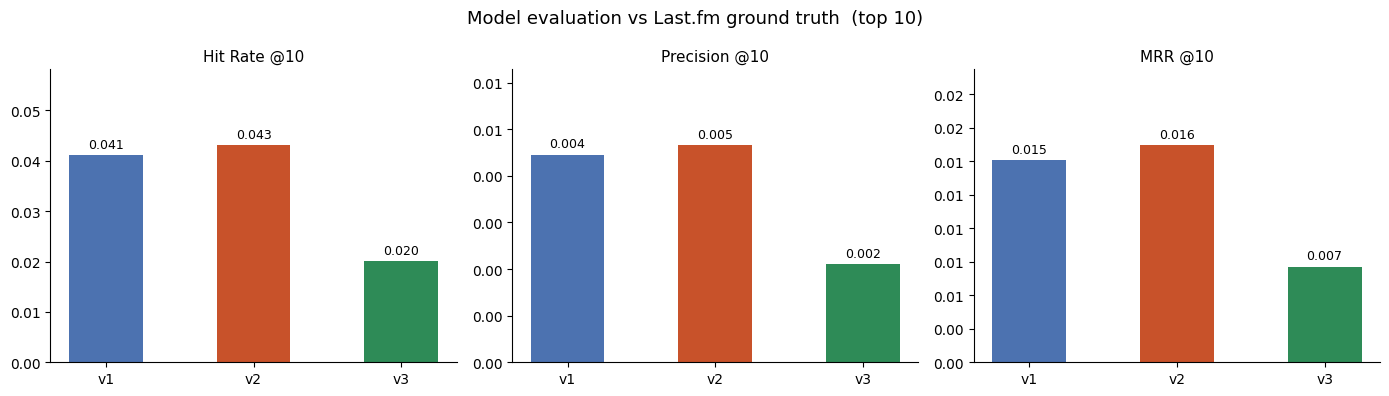

Plot saved to ../data/model_evaluation.png


In [13]:
metrics     = ['hit_rate', 'precision', 'mrr']
metric_labels = [f'Hit Rate @{N_RESULTS}', f'Precision @{N_RESULTS}', f'MRR @{N_RESULTS}']
model_labels  = list(results.keys())
colours       = ['#4C72B0', '#C8522A', '#2E8B57']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'Model evaluation vs Last.fm ground truth  (top {N_RESULTS})', fontsize=13)

for ax, metric, title in zip(axes, metrics, metric_labels):
    values = [results[m][metric] for m in model_labels]
    bars   = ax.bar(model_labels, values, color=colours, width=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, min(1.0, max(values) * 1.35) if max(values) > 0 else 0.1)
    ax.set_xticks(range(len(model_labels)))
    ax.set_xticklabels(['v1', 'v2', 'v3'], fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to ../data/model_evaluation.png')

In [ ]:
# Per-seed-album detail — useful for spotting where models diverge
rows = []
for seed_id, known_similar in ground_truth.items():
    seed_name = mb_lookup.loc[mb_lookup['album_id'] == seed_id, 'album_name']
    seed_name = seed_name.iloc[0] if not seed_name.empty else str(seed_id)

    row = {'seed_album': seed_name, 'n_known_similar': len(known_similar)}
    for label, model, X, ids, id2row in [
        ('hits_v1', model_v1, X_v1, ids_v1, id2row_v1),
        ('hits_v2', model_v2, X_v2, ids_v2, id2row_v2),
        ('hits_v3', model_v3, X_v3, ids_v3, id2row_v3),
    ]:
        recs = get_recommendations(seed_id, N_RESULTS, model, X, ids, id2row, mb_index)
        if recs is None:
            row[label] = None
        else:
            row[label] = len(set(recs) & known_similar)
    rows.append(row)

detail_df = pd.DataFrame(rows).sort_values('hits_v1', ascending=False)
print(f'Albums where v3 finds more hits than v1:')
improved = detail_df[detail_df['hits_v3'].fillna(0) > detail_df['hits_v1'].fillna(0)]
print(improved.head(20).to_string(index=False))

print(f'\nAlbums where v1 finds more hits than v3:')
regressed = detail_df[detail_df['hits_v1'].fillna(0) > detail_df['hits_v3'].fillna(0)]
print(regressed.head(20).to_string(index=False))

In [14]:
# ── Load tuned weights and apply to knn-v2 / knn-v3 ─────────────────────
import json

with open(f'{DATA_DIR}/best_weights.json') as f:
    best_weights = json.load(f)

# ── V2 weights ────────────────────────────────────────────────────────────
W_TAGS        = best_weights['v2']['W_TAGS']
W_LABELS      = best_weights['v2']['W_LABELS']
W_TYPES       = best_weights['v2']['W_TYPES']
W_RATINGS     = best_weights['v2']['W_RATINGS']
W_COUNTRY     = best_weights['v2']['W_COUNTRY']
W_TRACK_STATS = best_weights['v2']['W_TRACK_STATS']

print('V2 weights loaded:')
for k, v in best_weights['v2'].items():
    print(f'  {k:<18} = {v}')

# ── V3 weights (includes all V2 weights + contributor blocks) ─────────────
W_TAGS_V3        = best_weights['v3']['W_TAGS']
W_LABELS_V3      = best_weights['v3']['W_LABELS']
W_TYPES_V3       = best_weights['v3']['W_TYPES']
W_RATINGS_V3     = best_weights['v3']['W_RATINGS']
W_COUNTRY_V3     = best_weights['v3']['W_COUNTRY']
W_TRACK_STATS_V3 = best_weights['v3']['W_TRACK_STATS']
W_ROLE_FAMILY    = best_weights['v3']['W_ROLE_FAMILY']
W_INSTRUMENT     = best_weights['v3']['W_INSTRUMENT']
W_CONTRIB_CNT    = best_weights['v3']['W_CONTRIB_CNT']

print('\nV3 weights loaded:')
for k, v in best_weights['v3'].items():
    print(f'  {k:<18} = {v}')

# ── Rebuild and save both models with tuned weights ───────────────────────
import os, joblib
from scipy.sparse import hstack, save_npz
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

def build_and_save(weights, model_dir):
    os.makedirs(f'{DATA_DIR}/{model_dir}', exist_ok=True)

    blocks = [
        X_tags        * weights.get('W_TAGS',        1.0),
        X_labels      * weights.get('W_LABELS',      1.0),
        X_types       * weights.get('W_TYPES',       1.0),
        X_ratings     * weights.get('W_RATINGS',     1.0),
        X_country     * weights.get('W_COUNTRY',     0.0),
        X_track_stats * weights.get('W_TRACK_STATS', 0.0),
    ]
    if weights.get('W_ROLE_FAMILY', 0.0) > 0:
        blocks += [
            X_role_family * weights.get('W_ROLE_FAMILY', 0.0),
            X_instrument  * weights.get('W_INSTRUMENT',  0.0),
            X_contrib_cnt * weights.get('W_CONTRIB_CNT', 0.0),
        ]

    X_full      = hstack(blocks).tocsr()
    col_nnz     = np.diff(X_full.tocsc().indptr)
    row_lengths = np.diff(X_full.indptr)
    has_feat    = row_lengths > 0
    nonempty    = np.where(has_feat)[0]
    col_vals    = col_nnz[X_full.indices]
    max_col     = np.zeros(X_full.shape[0], dtype=col_nnz.dtype)
    max_col[nonempty] = np.maximum.reduceat(col_vals, X_full.indptr[nonempty])
    safe_thresh = int(max_col[has_feat].min())
    X_pruned    = X_full[:, col_nnz >= safe_thresh]

    X_ann  = X_pruned[has_feat].copy()
    ids_ann = np.array(album_id_order)[has_feat]
    np.nan_to_num(X_ann.data, nan=0.0, copy=False)
    X_ann.eliminate_zeros()
    X_norm = normalize(X_ann, norm='l2')

    model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
    model.fit(X_norm)

    suffix = model_dir.replace('model', '').replace('_', '') or ''
    joblib.dump(model,  f'{DATA_DIR}/{model_dir}/knn_model{suffix}.joblib')
    save_npz(f'{DATA_DIR}/{model_dir}/X_knn_norm{suffix}.npz', X_norm)
    np.save(f'{DATA_DIR}/{model_dir}/album_ids_annotated{suffix}.npy', ids_ann)
    np.save(f'{DATA_DIR}/{model_dir}/has_features{suffix}.npy', has_feat)

    print(f'Saved to {model_dir}/  '
          f'({X_norm.shape[0]:,} albums x {X_norm.shape[1]:,} features)')


print('\nRebuilding V2 with tuned weights...')
build_and_save(best_weights['v2'], 'model_v2')

print('Rebuilding V3 with tuned weights...')
build_and_save(best_weights['v3'], 'model_v3')

print('\nDone. Models saved and ready for use in app_sql_v3.py')

V2 weights loaded:
  W_TAGS             = 1.0
  W_LABELS           = 1.0
  W_TYPES            = 1.0
  W_RATINGS          = 1.0
  W_COUNTRY          = 0.05
  W_TRACK_STATS      = 0.1

V3 weights loaded:
  W_TAGS             = 1.0
  W_LABELS           = 1.0
  W_TYPES            = 1.0
  W_RATINGS          = 1.0
  W_COUNTRY          = 0.05
  W_TRACK_STATS      = 0.1
  W_ROLE_FAMILY      = 0.23473941999051612
  W_INSTRUMENT       = 0.1116840167145593
  W_CONTRIB_CNT      = 0.3104784682440281

Rebuilding V2 with tuned weights...


NameError: name 'X_tags' is not defined